# Comprehensive Latent Space Analysis

This notebook provides a complete analysis of a model's learned latent space dynamics. It loads the results from a single `latent_space_analysis.npz` file (generated by `evaluate_latent_space.py`) and visualizes:

1.  **Summary Metrics:** The overall MSE and R² score for the latent space rollout.
2.  **Rollout Error:** The MSE of the latent space prediction at each timestep.
3.  **Latent Trajectories:** A comparison of the predicted vs. ground truth evolution for individual latent dimensions.
4.  **Koopman Mode Evolution:** The evolution of the latent state projected onto the learned Koopman eigenvectors.

### 1. Setup and Imports

In [ ]:
from pathlib import Path
import numpy as np

# Make sure your packages are installed in editable mode
from mhd_surrogate_core.plotting import (
    plot_latent_rollout_error,
    plot_latent_trajectories,
    plot_koopman_mode_evolution
)

### 2. Specify Evaluation File Path and Analyze

**Action Required:** Change the `eval_file_path` variable below to point to the specific `latent_space_analysis.npz` file you want to analyze.

2025-07-08 15:41:11,848 - INFO - Loading latent rollout error from /cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/experiments/study_1_param_sweep/output/param_sweep_07_07_25/lr_1e-4_ld_4096_wr_1.0_wp_1.0_wl_10.0_we_0.1/eval/latent_space_analysis_train_val.npz...


--- LATENT SPACE EVALUATION SUMMARY ---
Average Latent Space Rollout MSE: 0.002494
Latent Space R-squared (R²) Score: -0.1459


--- Latent Space Error Plot ---


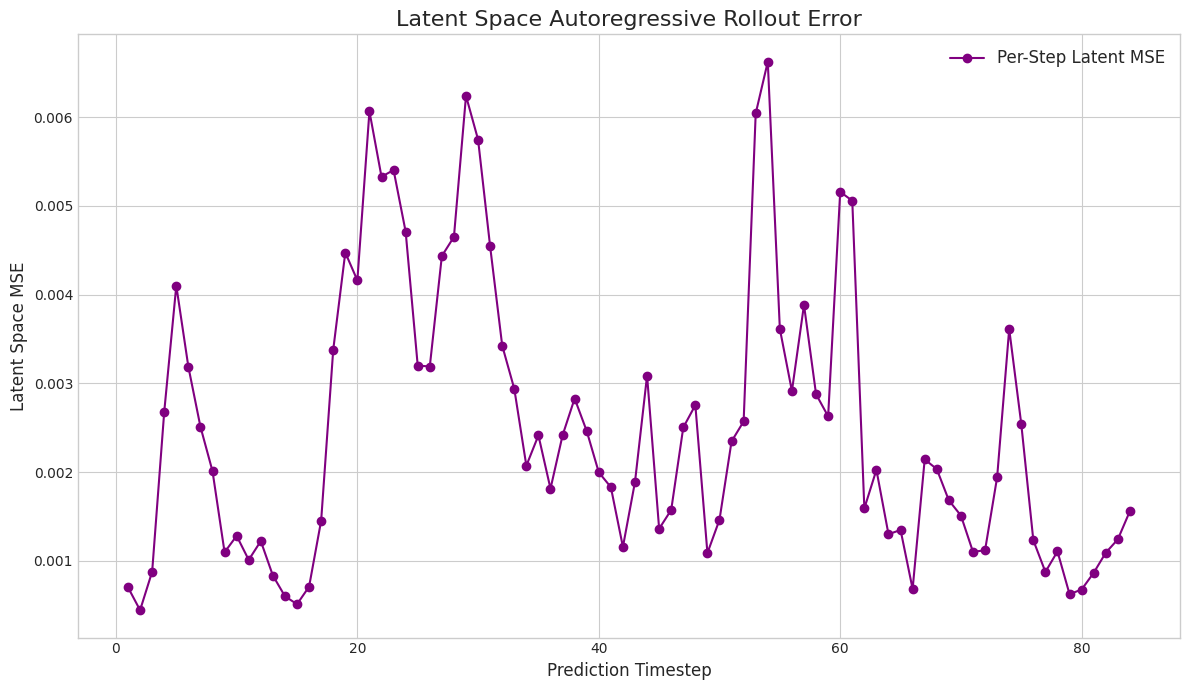

2025-07-08 15:41:12,074 - INFO - Loading latent trajectories from /cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/experiments/study_1_param_sweep/output/param_sweep_07_07_25/lr_1e-4_ld_4096_wr_1.0_wp_1.0_wl_10.0_we_0.1/eval/latent_space_analysis_train_val.npz...



--- Latent Trajectory Plot ---


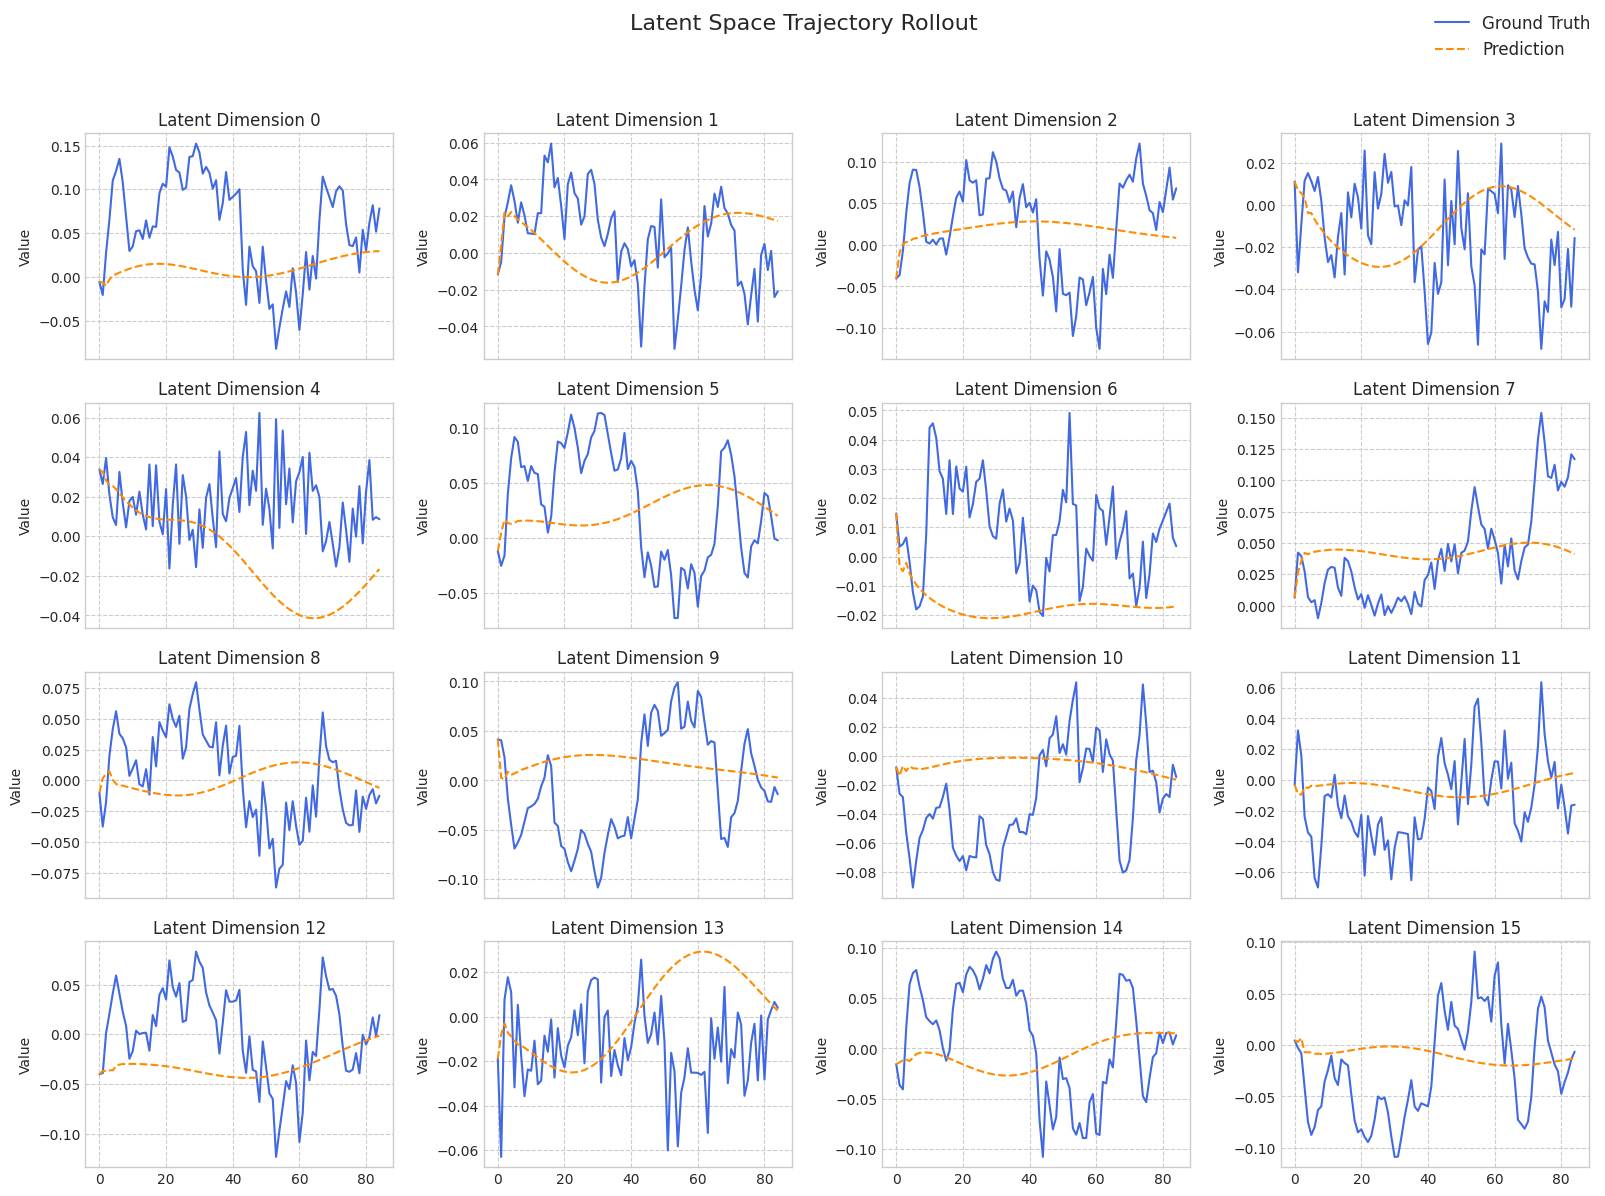

2025-07-08 15:41:14,733 - INFO - Loading Koopman mode data from /cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/experiments/study_1_param_sweep/output/param_sweep_07_07_25/lr_1e-4_ld_4096_wr_1.0_wp_1.0_wl_10.0_we_0.1/eval/latent_space_analysis_train_val.npz...



--- Koopman Mode Evolution Plot ---


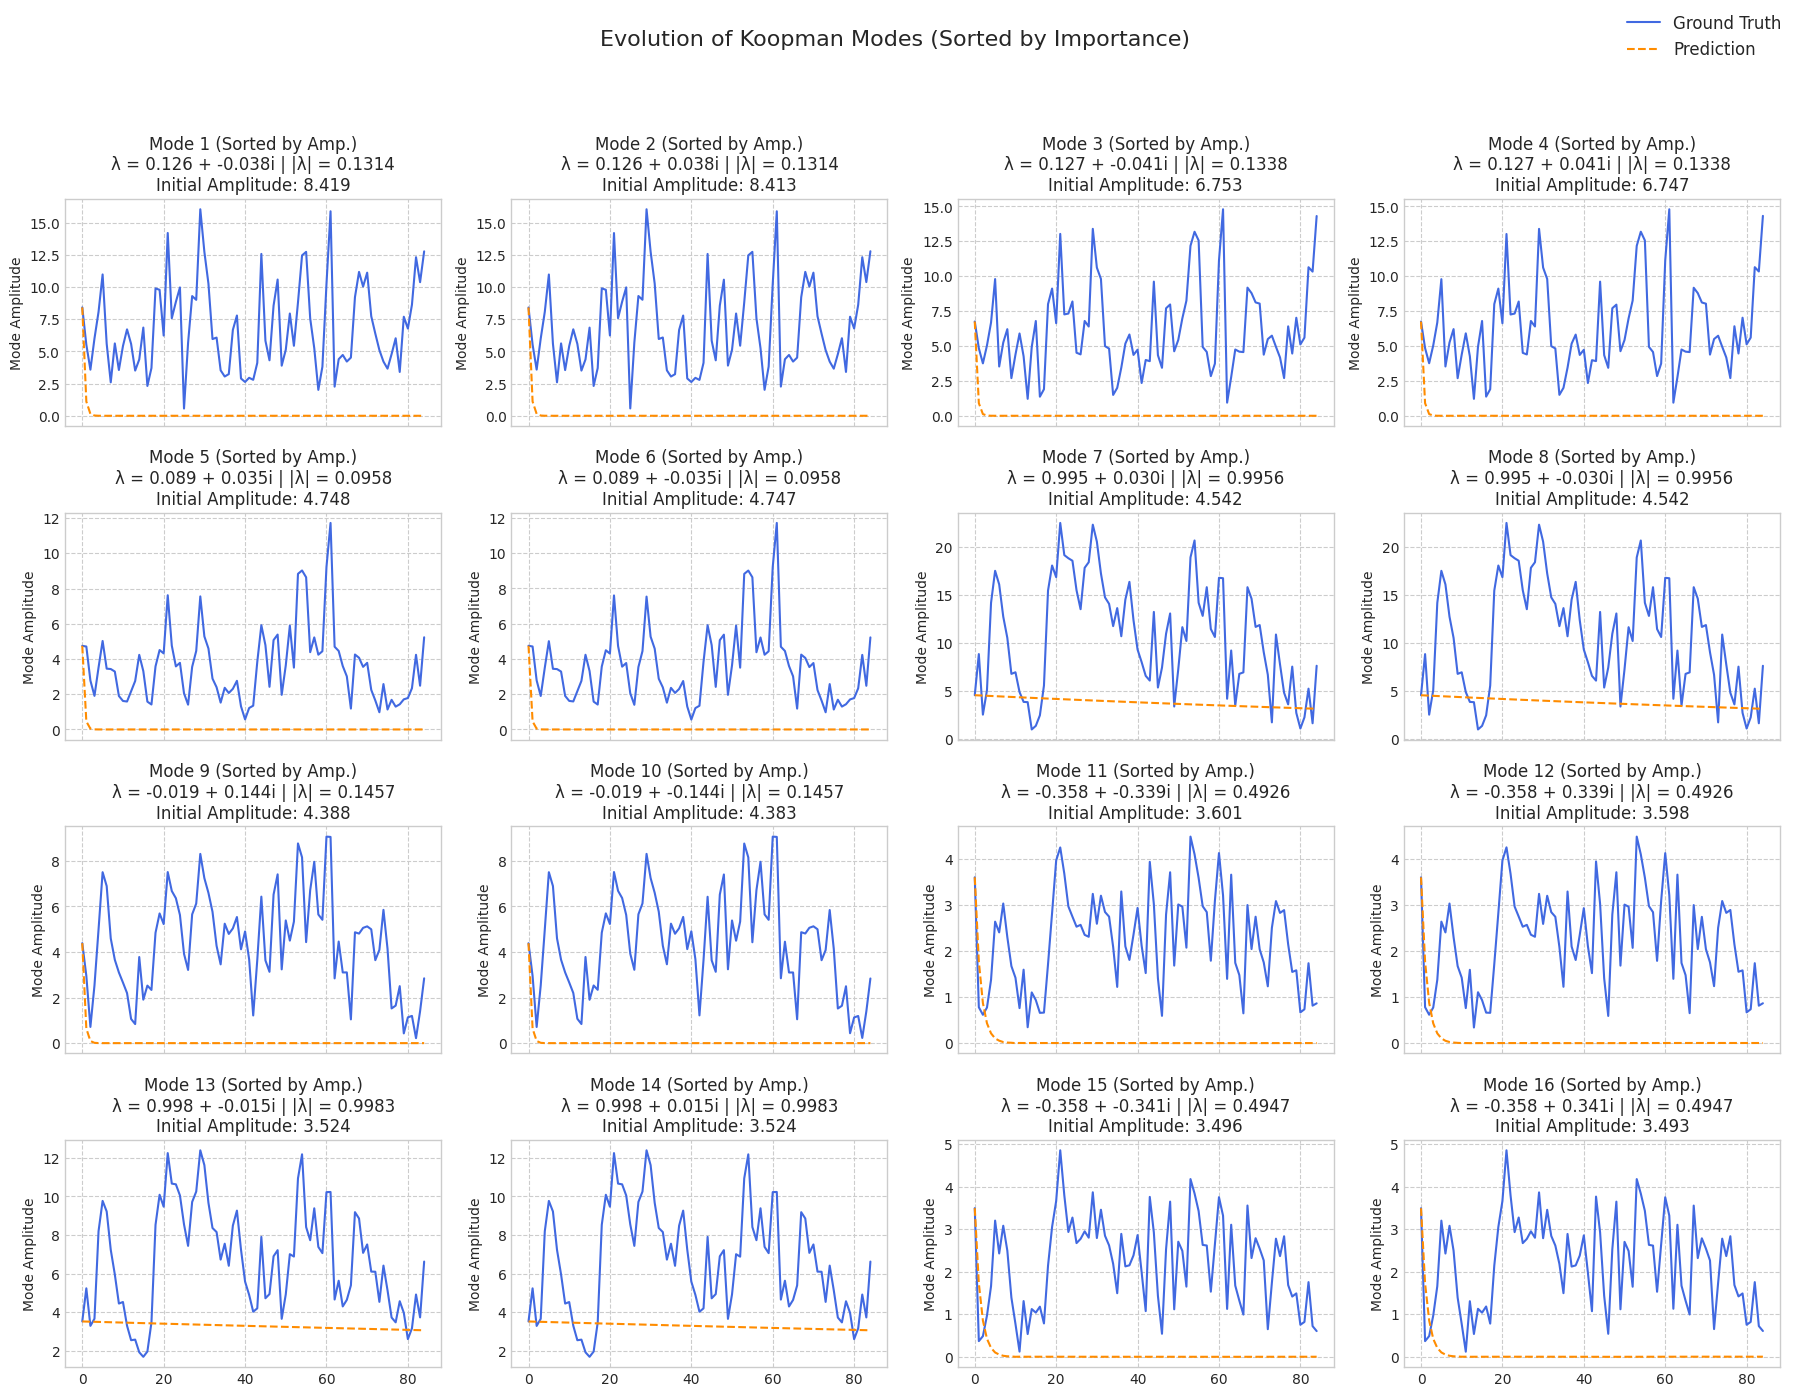

In [2]:
# Example path - update this to your specific run's output.
eval_file_path = Path("/cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/experiments/study_1_param_sweep/output/param_sweep_07_07_25/lr_1e-4_ld_4096_wr_1.0_wp_1.0_wl_10.0_we_0.1/eval/latent_space_analysis_train_val.npz")

if eval_file_path.exists():
    # --- Load Summary Metrics ---
    with np.load(eval_file_path) as data:
        avg_mse = data['avg_rollout_mse']
        r_squared = data['r_squared_latent']
    
    print("--- LATENT SPACE EVALUATION SUMMARY ---")
    print(f"Average Latent Space Rollout MSE: {avg_mse:.6f}")
    print(f"Latent Space R-squared (R²) Score: {r_squared:.4f}\n")
    
    # --- Generate Plots ---
    print("\n--- Latent Space Error Plot ---")
    plot_latent_rollout_error(eval_file_path)
    
    print("\n--- Latent Trajectory Plot ---")
    plot_latent_trajectories(eval_file_path, num_dims_to_plot=16)

    print("\n--- Koopman Mode Evolution Plot ---")
    plot_koopman_mode_evolution(eval_file_path, num_modes_to_plot=16)
else:
    print(f"ERROR: Evaluation file not found at {eval_file_path}")
    print("Please run evaluate_latent_space.py first and/or update the path.")